# 02 描述性统计与可视化


本笔记本在重建清洗后样本的基础上，完成描述性统计、相关系数分析和趋势图绘制。


## 第二部分：描述性统计


In [8]:
# Descriptive statistics by full sample / SOE / non-SOE
from scipy import stats

stat_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS']

def describe_group(df_group, vars_list):
    stats_tbl = df_group[vars_list].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    stats_tbl = stats_tbl.loc[['count', 'mean', 'std', '10%', '25%', '50%', '75%', '90%']]
    stats_tbl = stats_tbl.rename(index={'count': 'N', '50%': 'Median'})
    return stats_tbl.T

# Three panels required by the rubric
desc_all = describe_group(df, stat_vars)
desc_soe = describe_group(df[df['SOE'] == 1], stat_vars)
desc_nonsoe = describe_group(df[df['SOE'] == 0], stat_vars)

print('Descriptive statistics - Full sample:')
print(desc_all.round(4))
print()
print('Descriptive statistics - SOE sample:')
print(desc_soe.round(4))
print()
print('Descriptive statistics - Non-SOE sample:')
print(desc_nonsoe.round(4))

# Mean difference t-tests (SOE vs non-SOE)
test_rows = []
for var in stat_vars:
    x = df.loc[df['SOE'] == 1, var].dropna()
    y = df.loc[df['SOE'] == 0, var].dropna()
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
    test_rows.append({
        'Variable': var,
        'Mean_SOE': x.mean(),
        'Mean_NonSOE': y.mean(),
        'Mean_Diff(SOE-NonSOE)': x.mean() - y.mean(),
        't_stat': t_stat,
        'p_value': p_val
    })

ttest_table = pd.DataFrame(test_rows)
print()
print('Mean difference t-tests (SOE vs Non-SOE):')
print(ttest_table.round(4))

# Save all descriptive outputs
with pd.ExcelWriter(os.path.join(OUTPUT_PATH, 'descriptive_statistics.xlsx')) as writer:
    desc_all.to_excel(writer, sheet_name='Full_Sample')
    desc_soe.to_excel(writer, sheet_name='SOE')
    desc_nonsoe.to_excel(writer, sheet_name='NonSOE')
    ttest_table.to_excel(writer, sheet_name='Mean_Diff_ttest', index=False)

print('Saved: output/descriptive_statistics.xlsx')



Descriptive statistics - Full sample:
               N     mean     std      10%      25%   Median      75%      90%
Lev     182986.0   0.3685  0.2023   0.1070   0.2034   0.3552   0.5157   0.6502
NPR     182986.0   0.0427  0.0604  -0.0050   0.0130   0.0380   0.0708   0.1098
Size    182986.0  22.1040  1.3112  20.6638  21.1894  21.8801  22.7925  23.8375
Tang    182986.0   0.1519  0.1436   0.0071   0.0379   0.1111   0.2246   0.3596
Growth  182986.0   0.0629  0.3695  -0.1869   0.0000   0.0000   0.0000   0.3431
NDTS    182986.0   0.0257  0.0198   0.0053   0.0114   0.0213   0.0348   0.0509

Descriptive statistics - SOE sample:
              N     mean     std      10%      25%   Median      75%      90%
Lev     60302.0   0.4398  0.2101   0.1473   0.2813   0.4432   0.6023   0.7229
NPR     60302.0   0.0390  0.0531  -0.0013   0.0103   0.0308   0.0613   0.1009
Size    60302.0  22.7891  1.4774  21.0685  21.7316  22.5903  23.6559  24.7151
Tang    60302.0   0.1782  0.1750   0.0038   0.0335   0.1211

### 2.2 相关系数矩阵


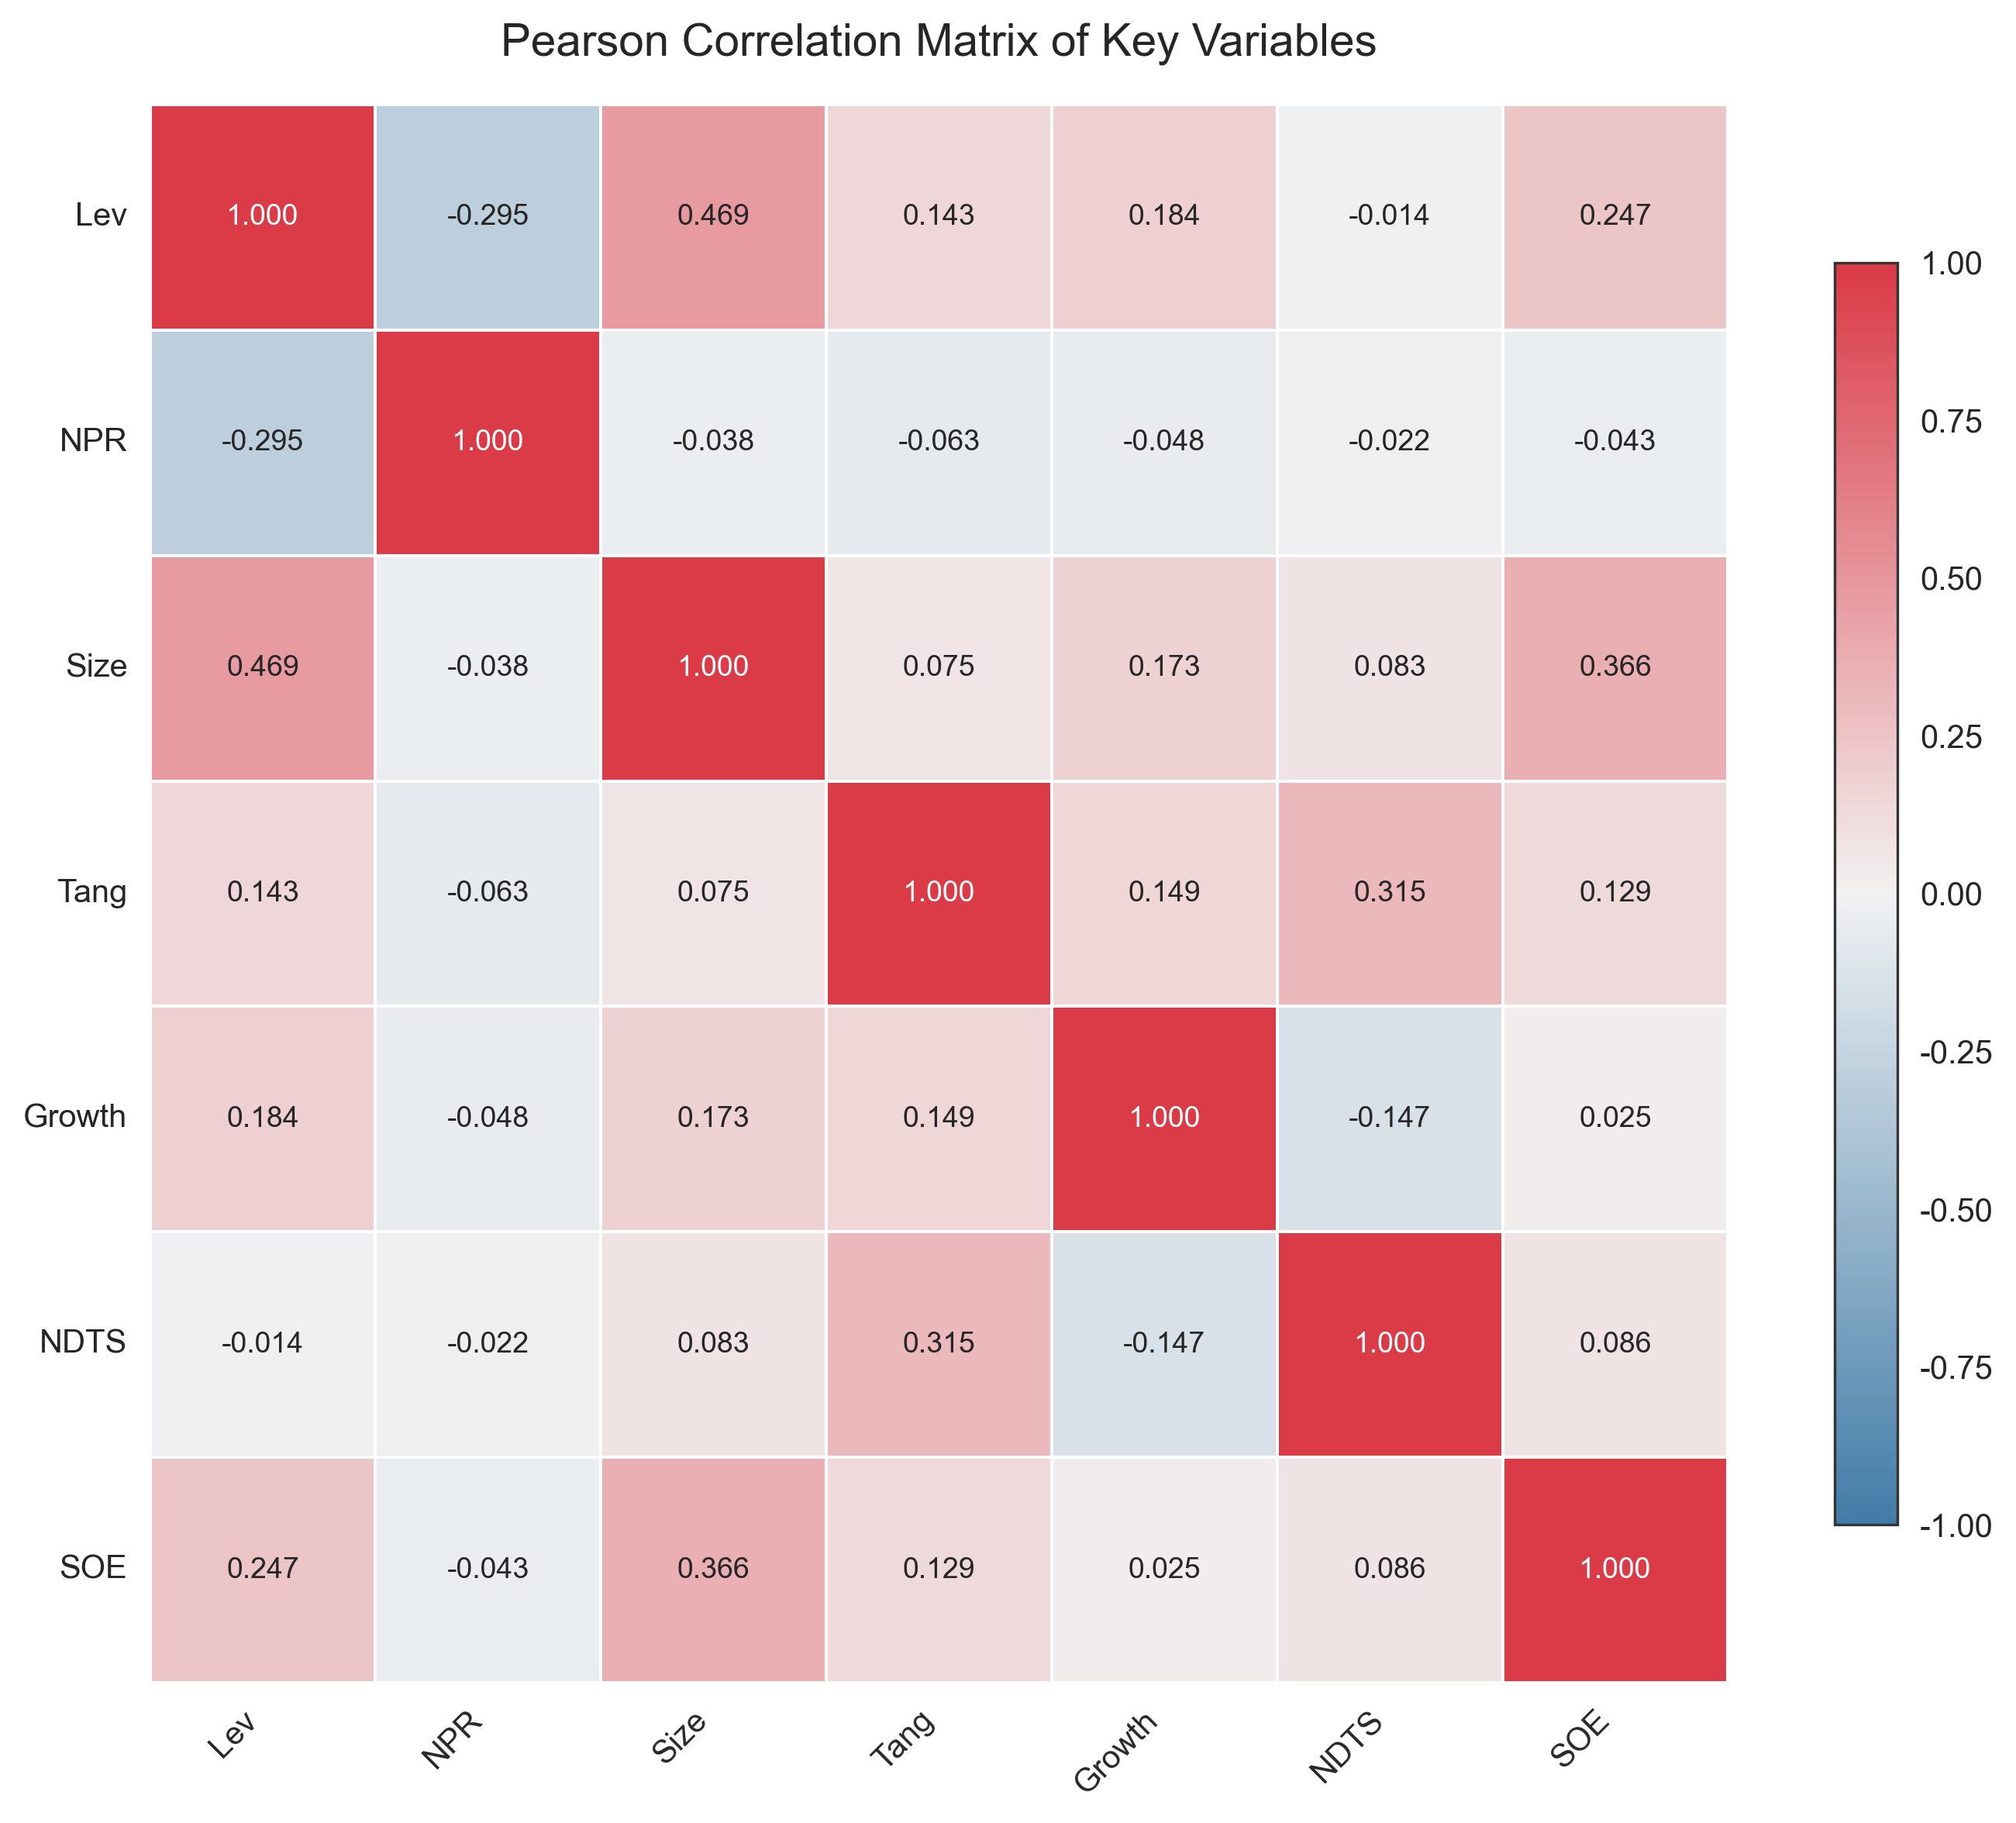

Correlation matrix saved

Starred correlation matrix:
              Lev        NPR       Size       Tang     Growth       NDTS  \
Lev      1.000***  -0.295***   0.469***   0.143***   0.184***  -0.014***   
NPR     -0.295***   1.000***  -0.038***  -0.063***  -0.048***  -0.022***   
Size     0.469***  -0.038***   1.000***   0.075***   0.173***   0.083***   
Tang     0.143***  -0.063***   0.075***   1.000***   0.149***   0.315***   
Growth   0.184***  -0.048***   0.173***   0.149***   1.000***  -0.147***   
NDTS    -0.014***  -0.022***   0.083***   0.315***  -0.147***   1.000***   
SOE      0.247***  -0.043***   0.366***   0.129***   0.025***   0.086***   

              SOE  
Lev      0.247***  
NPR     -0.043***  
Size     0.366***  
Tang     0.129***  
Growth   0.025***  
NDTS     0.086***  
SOE      1.000***  
Saved: output/correlation_matrix.xlsx


In [10]:
from plot_config import styled_heatmap, save_figure
from scipy import stats

corr_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']
corr_matrix = df[corr_vars].corr()

# Build p-value matrix for significance marking
p_matrix = pd.DataFrame(np.ones_like(corr_matrix), columns=corr_matrix.columns, index=corr_matrix.index)
for i in corr_vars:
    for j in corr_vars:
        if i == j:
            p_matrix.loc[i, j] = 0.0
        else:
            _, p_val = stats.pearsonr(df[i], df[j])
            p_matrix.loc[i, j] = p_val

# Add stars to the printed/exported table
starred_corr = corr_matrix.copy().astype(object)
for i in corr_vars:
    for j in corr_vars:
        val = corr_matrix.loc[i, j]
        p_val = p_matrix.loc[i, j]
        stars = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.1 else ''))
        starred_corr.loc[i, j] = f"{val:.3f}{stars}"

plt.figure(figsize=(10, 8))
ax = styled_heatmap(corr_matrix)
plt.title('Pearson Correlation Matrix of Key Variables', fontsize=14, pad=15)
plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'correlation_matrix.png'))
plt.show()

print('Correlation matrix saved')
print()
print('Starred correlation matrix:')
print(starred_corr)

with pd.ExcelWriter(os.path.join(OUTPUT_PATH, 'correlation_matrix.xlsx')) as writer:
    corr_matrix.to_excel(writer, sheet_name='corr')
    p_matrix.to_excel(writer, sheet_name='p_value')
    starred_corr.to_excel(writer, sheet_name='corr_with_stars')

print('Saved: output/correlation_matrix.xlsx')



### 2.3 时序趋势图


In [ ]:
from plot_config import styled_lineplot, styled_boxplot, COLORS, save_figure

# Compute annual means by ownership type
trend_data = df.groupby(['year', 'SOE'])[['Lev', 'NPR']].mean().reset_index()
# Rename SOE labels for plotting
trend_data['Ownership'] = trend_data['SOE'].map({0: 'Non-SOE', 1: 'SOE'})

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
ax1 = styled_lineplot(data=trend_data, x='year', y='Lev', hue='Ownership',
                      palette=[COLORS['nonsoe'], COLORS['soe']])
plt.title('Time Trend of Leverage (Lev)', fontsize=14)
plt.ylabel('Leverage (Lev)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Ownership')

plt.subplot(2, 1, 2)
ax2 = styled_lineplot(data=trend_data, x='year', y='NPR', hue='Ownership',
                      palette=[COLORS['nonsoe'], COLORS['soe']])
plt.title('Time Trend of Net Profit Ratio (NPR)', fontsize=14)
plt.ylabel('Net Profit Ratio (NPR)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Ownership')

plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'trend_analysis.png'))
plt.show()

# Yearly boxplot for Lev
plt.figure(figsize=(12, 6))
ax = styled_boxplot(data=df, x='year', y='Lev', palette=[COLORS['primary']])
plt.title('Yearly Boxplot of Leverage (Lev)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Leverage (Lev)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'lev_boxplot.png'))
plt.show()